In [1]:
import yfinance as yf
import datetime
import pandas as pd
import scipy as sp
import numpy as np
import matplotlib.pyplot as plt

import scipy as sp

from statsmodels.tsa.stattools import pacf
from statsmodels.tsa.stattools import acf

import random

from tqdm import tqdm

/Users/hiroku007/miniforge3/envs/trailstone_assessment/lib/python3.8/site-packages/yfinance/base.py:48: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  _empty_series = pd.Series()


In [13]:
spy = yf.Ticker('SPY')


In [14]:
end_date = datetime.datetime.now()
start_date = end_date - datetime.timedelta(57)
spy_hist = spy.history(interval = '2m', start = start_date ,end=end_date)

print(spy_hist)

                                 Open        High         Low       Close  \
Datetime                                                                    
2024-02-09 09:30:00-05:00  498.839996  498.929993  498.489990  498.820007   
2024-02-09 09:32:00-05:00  498.809998  499.029999  498.700012  499.015015   
2024-02-09 09:34:00-05:00  499.000000  499.209991  498.980011  499.130005   
2024-02-09 09:36:00-05:00  499.140015  499.204987  498.850800  498.964996   
2024-02-09 09:38:00-05:00  498.970001  499.029999  498.845001  499.029999   
...                               ...         ...         ...         ...   
2024-03-27 11:30:00-04:00  519.710022  519.765015  519.530029  519.569702   
2024-03-27 11:32:00-04:00  519.580017  519.687988  519.544983  519.659973   
2024-03-27 11:34:00-04:00  519.669983  519.784973  519.630005  519.784973   
2024-03-27 11:36:00-04:00  519.784973  519.900024  519.760010  519.896973   
2024-03-27 11:38:00-04:00  519.890015  519.890015  519.890015  519.890015   

In [15]:
spy_hist = spy_hist.reset_index()

In [16]:
spy_hist['Date'] = spy_hist.apply(lambda row: row['Datetime'].date(), axis=1)
spy_hist['Time'] = spy_hist.apply(lambda row: row['Datetime'].time(), axis=1)


spy_hist['logClose'] = np.log(spy_hist['Close'])
spy_hist['logOpen'] = np.log(spy_hist['Open'])




In [17]:
spy_hist

,Datetime,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains,Date,Time,logClose,logOpen
0,2024-02-09 09:30:00-05:00,498.839996,498.929993,498.489990,498.820007,2015648,0.0,0.0,0.0,2024-02-09,09:30:00,6.212245,6.212285
1,2024-02-09 09:32:00-05:00,498.809998,499.029999,498.700012,499.015015,455613,0.0,0.0,0.0,2024-02-09,09:32:00,6.212636,6.212225
2,2024-02-09 09:34:00-05:00,499.000000,499.209991,498.980011,499.130005,310135,0.0,0.0,0.0,2024-02-09,09:34:00,6.212867,6.212606
3,2024-02-09 09:36:00-05:00,499.140015,499.204987,498.850800,498.964996,311372,0.0,0.0,0.0,2024-02-09,09:36:00,6.212536,6.212887
4,2024-02-09 09:38:00-05:00,498.970001,499.029999,498.845001,499.029999,284167,0.0,0.0,0.0,2024-02-09,09:38:00,6.212666,6.212546
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6300,2024-03-27 11:30:00-04:00,519.710022,519.765015,519.530029,519.569702,449662,0.0,0.0,0.0,2024-03-27,11:30:00,6.253001,6.253271
6301,2024-03-27 11:32:00-04:00,519.580017,519.687988,519.544983,519.659973,166900,0.0,0.0,0.0,2024-03-27,11:32:00,6.253175,6.253021
6302,2024-03-27 11:34:00-04:00,519.669983,519.784973,519.630005,519.784973,200382,0.0,0.0,0.0,2024-03-27,11:34:00,6.253415,6.253194
6303,2024-03-27 11:36:00-04:00,519.784973,519.900024,519.760010,519.896973,243410,0.0,0.0,0.0,2024-03-27,11:36:00,6.253631,6.253415


In [18]:
spy_hist_date = spy_hist.groupby('Date')
log_returns = spy_hist_date.apply(lambda row: row['logClose']-row['logOpen'])


In [19]:
log_returns

Date            
2024-02-09  0      -0.000040
            1       0.000411
            2       0.000260
            3      -0.000351
            4       0.000120
                      ...   
2024-03-27  6300   -0.000270
            6301    0.000154
            6302    0.000221
            6303    0.000215
            6304    0.000000
Length: 6305, dtype: float64

In [20]:
counts, bin_edges = np.histogram(log_returns.dropna(), bins=100)
frequencies = counts/len(log_returns.dropna())


In [21]:
mean = log_returns.mean()
std = log_returns.std()

gaussian_fit = (1./np.sqrt(2*np.pi*std**2)) * np.exp(- (bin_edges - mean)**2 / (2*std**2))


In [22]:
len(log_returns)

6305

Text(0, 0.5, 'frequency')

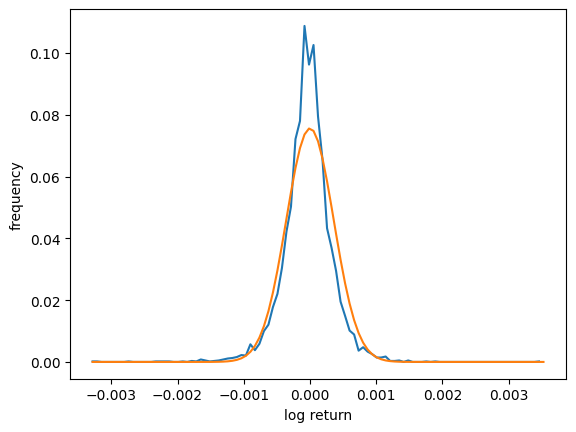

In [23]:
plt.plot(bin_edges[:100], counts/len(log_returns), label = 'log returns, empirical')
plt.plot(bin_edges, (bin_edges[1]-bin_edges[0])*gaussian_fit, label = 'log returns, gaussian fit')
plt.xlabel('log return')
plt.ylabel('frequency')
#plt.ylim((1/6045,0.2))

In [196]:
spy_hist['logReturns'] = spy_hist['logClose'] - spy_hist['logOpen']

In [197]:
cdf = np.cumsum(counts/len(log_returns))

delta_bin = bin_edges[1]-bin_edges[0]



In [198]:
cdf

array([1.67926113e-04, 1.67926113e-04, 1.67926113e-04, 1.67926113e-04,
       1.67926113e-04, 1.67926113e-04, 3.35852225e-04, 5.03778338e-04,
       5.03778338e-04, 5.03778338e-04, 5.03778338e-04, 5.03778338e-04,
       5.03778338e-04, 5.03778338e-04, 5.03778338e-04, 5.03778338e-04,
       5.03778338e-04, 5.03778338e-04, 6.71704450e-04, 6.71704450e-04,
       8.39630563e-04, 1.00755668e-03, 1.00755668e-03, 1.34340890e-03,
       1.84718724e-03, 2.18303946e-03, 2.51889169e-03, 2.68681780e-03,
       4.03022670e-03, 4.86985726e-03, 6.88497061e-03, 8.06045340e-03,
       9.40386230e-03, 1.12510495e-02, 1.37699412e-02, 1.86397985e-02,
       2.46851385e-02, 3.10663308e-02, 3.97984887e-02, 4.93702771e-02,
       6.54911839e-02, 8.86649874e-02, 1.22921914e-01, 1.82535684e-01,
       2.55079765e-01, 3.53484467e-01, 4.65155332e-01, 5.89420655e-01,
       6.96893367e-01, 7.90260285e-01, 8.57430730e-01, 9.00083963e-01,
       9.31150294e-01, 9.52812762e-01, 9.65910999e-01, 9.73971453e-01,
      

In [199]:
bin_edges

array([-6.78294807e-03, -6.63915687e-03, -6.49536566e-03, -6.35157446e-03,
       -6.20778325e-03, -6.06399205e-03, -5.92020084e-03, -5.77640964e-03,
       -5.63261844e-03, -5.48882723e-03, -5.34503603e-03, -5.20124482e-03,
       -5.05745362e-03, -4.91366241e-03, -4.76987121e-03, -4.62608000e-03,
       -4.48228880e-03, -4.33849759e-03, -4.19470639e-03, -4.05091518e-03,
       -3.90712398e-03, -3.76333277e-03, -3.61954157e-03, -3.47575036e-03,
       -3.33195916e-03, -3.18816796e-03, -3.04437675e-03, -2.90058555e-03,
       -2.75679434e-03, -2.61300314e-03, -2.46921193e-03, -2.32542073e-03,
       -2.18162952e-03, -2.03783832e-03, -1.89404711e-03, -1.75025591e-03,
       -1.60646470e-03, -1.46267350e-03, -1.31888229e-03, -1.17509109e-03,
       -1.03129988e-03, -8.87508680e-04, -7.43717475e-04, -5.99926270e-04,
       -4.56135066e-04, -3.12343861e-04, -1.68552656e-04, -2.47614516e-05,
        1.19029753e-04,  2.62820958e-04,  4.06612163e-04,  5.50403367e-04,
        6.94194572e-04,  

In [200]:
assumed_values = bin_edges[:100] + (np.diff(bin_edges))/2

In [201]:
assumed_values[51]

0.0006222989695736647

In [202]:
len(counts[counts!=0])

58

In [203]:
assumed_increments = []
last_assumed_value = assumed_values[0]
for index, count in enumerate(counts):
    if count>0:
        assumed_increments.append((last_assumed_value + assumed_values[index])/2)
        last_assumed_value = assumed_values[index]

assumed_increments = np.asarray(assumed_increments)

In [204]:
np.asarray(assumed_increments)

array([-6.71105247e-03, -6.27967886e-03, -5.77640964e-03, -4.91366241e-03,
       -3.97901958e-03, -3.76333277e-03, -3.54764597e-03, -3.33195916e-03,
       -3.18816796e-03, -3.04437675e-03, -2.90058555e-03, -2.75679434e-03,
       -2.61300314e-03, -2.46921193e-03, -2.32542073e-03, -2.18162952e-03,
       -2.03783832e-03, -1.89404711e-03, -1.75025591e-03, -1.60646470e-03,
       -1.46267350e-03, -1.31888229e-03, -1.17509109e-03, -1.03129988e-03,
       -8.87508680e-04, -7.43717475e-04, -5.99926270e-04, -4.56135066e-04,
       -3.12343861e-04, -1.68552656e-04, -2.47614516e-05,  1.19029753e-04,
        2.62820958e-04,  4.06612163e-04,  5.50403367e-04,  6.94194572e-04,
        8.37985777e-04,  9.81776981e-04,  1.12556819e-03,  1.26935939e-03,
        1.41315060e-03,  1.55694180e-03,  1.70073300e-03,  1.84452421e-03,
        1.98831541e-03,  2.13210662e-03,  2.27589782e-03,  2.41968903e-03,
        2.56348023e-03,  2.70727144e-03,  2.85106264e-03,  3.06674945e-03,
        3.49812306e-03,  

In [205]:
log_returns_deviation = np.zeros(100000)

for r in tqdm(range(100000)):
    for i in range(int(4*30)):
        index_list = np.where(random.uniform(0,1)>cdf)[0]
        if len(index_list)==0:
            index = 0
        else:
            index = np.max(index_list) + 1
        log_returns_deviation[r] += bin_edges[index] + delta_bin/2


100%|█████████████████████████████████| 100000/100000 [00:30<00:00, 3241.64it/s]


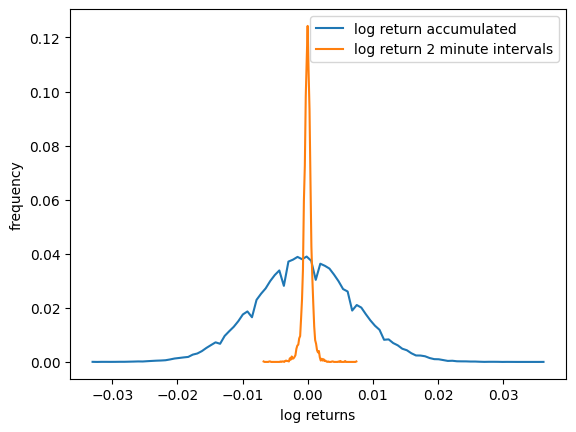

In [206]:
counts_cumulated, bins_cumulated = np.histogram(log_returns_deviation, bins=100)

plt.plot(bins_cumulated[:100],counts_cumulated/len(log_returns_deviation), label = 'log return accumulated')
plt.plot(bin_edges[:100], counts/len(log_returns), label = 'log return 2 minute intervals')
plt.xlabel('log returns')
plt.ylabel('frequency')
plt.legend()


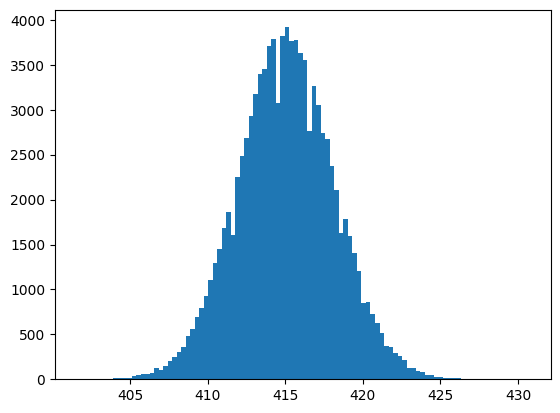

In [207]:
current_price = (spy.info['ask']*spy.info['askSize'] + spy.info['bid']*spy.info['bidSize'])/(spy.info['askSize'] + spy.info['bidSize'])

plt.hist(np.exp(np.log(current_price) + log_returns_deviation) - (np.mean(np.exp(np.log(current_price) + log_returns_deviation))-current_price), bins = 100)
plt.show()

In [208]:
current_price = (spy.info['ask']*spy.info['askSize'] + spy.info['bid']*spy.info['bidSize'])/(spy.info['askSize'] + spy.info['bidSize'])


In [209]:
outcome_prices = np.exp(np.log(current_price) + log_returns_deviation)

In [210]:
mean_payout = 0
payouts = np.zeros(len(outcome_prices))
for index, elem in enumerate(outcome_prices):
    payouts[index] = ( - max(0, elem - 512) + max(0, elem - 511) - max(0, 513 - elem) + max(0, 514 - elem))
    
payouts.mean()

1.0

In [211]:
mean_payout = 0
payouts = np.zeros(len(outcome_prices))
for index, elem in enumerate(outcome_prices):
    payouts[index] = ( - max(0, elem - 512) + max(0, elem - 511) - max(0, 513 - elem) + max(0, 514 - elem))
    
payouts.mean()

1.0

In [212]:
np.mean(log_returns_deviation)

-0.00013518039601043459

In [213]:
payouts.sum()

100000.0

In [214]:
- max(0, 511.5-511) + max(0, 511.5 - 510) - max(0, 512 - 511.5) + max(0, 513 - 511.5)

2.0

(array([     0.,      0.,      0.,      0.,      0., 100000.,      0.,
             0.,      0.,      0.]),
 array([0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2, 1.3, 1.4, 1.5]),
 <BarContainer object of 10 artists>)

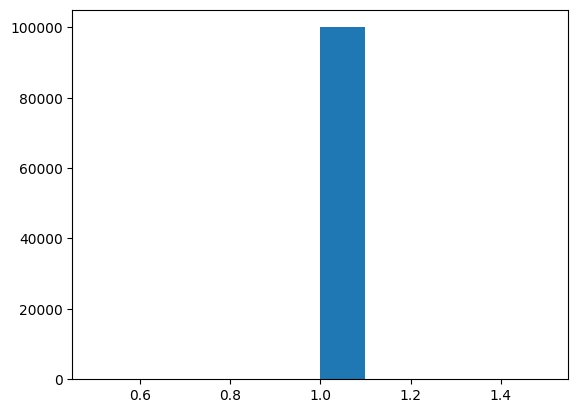

In [215]:
plt.hist(payouts)

In [216]:
payouts.mean()

1.0

In [217]:
print(len(payouts[payouts<1.3]))
print(len(payouts[payouts>1.3]))


100000
0


In [218]:
mean_payout = 0
for elem in outcome_prices:
    mean_payout+=max(0, elem-85)
mean_payout/len(outcome_prices)

329.9950130310375

In [219]:
mean_payout = 0
for elem in outcome_prices:
    mean_payout+=max(0, 86-elem)
mean_payout/len(outcome_prices)

0.0

In [220]:
mean_payout = 0
for elem in outcome_prices:
    mean_payout+=max(0, 87-elem)
mean_payout/len(outcome_prices)

0.0

In [221]:
0.73*730 - 0.27 * 1770

54.99999999999994

In [222]:
np.sum(
    np.logical_and(
        (np.exp(
            np.log(current_price) + log_returns_deviation
        ) - (np.mean(np.exp(np.log(current_price) + log_returns_deviation))-current_price)>770),
        (np.exp(
            np.log(current_price) + log_returns_deviation
        ) - (np.mean(np.exp(np.log(current_price) + log_returns_deviation))-current_price)<780)
    )
)/len(log_returns_deviation)


0.0

In [223]:
np.sum(
    np.logical_and(
        (np.exp(
            np.log(current_price) + log_returns_deviation
        ) - (np.mean(np.exp(np.log(current_price) + log_returns_deviation))-current_price)>504),
        (np.exp(
            np.log(current_price) + log_returns_deviation
        ) - (np.mean(np.exp(np.log(current_price) + log_returns_deviation))-current_price)<505)
    )
)/len(log_returns_deviation)

0.0

In [224]:
spy_hist

,Datetime,Open,High,Low,Close,Volume,Dividends,Stock Splits,Date,Time,logClose,logOpen,logReturns
0,2024-01-19 09:30:00-05:00,395.760010,395.850006,394.100006,394.600006,3136814,0.0,0.0,2024-01-19,09:30:00,5.977873,5.980808,-0.002935
1,2024-01-19 09:32:00-05:00,394.600006,394.929993,393.940002,394.820007,302961,0.0,0.0,2024-01-19,09:32:00,5.978430,5.977873,0.000557
2,2024-01-19 09:34:00-05:00,394.779999,395.029999,393.500000,393.609985,276817,0.0,0.0,2024-01-19,09:34:00,5.975361,5.978329,-0.002968
3,2024-01-19 09:36:00-05:00,393.649994,395.320007,393.640015,395.149994,224938,0.0,0.0,2024-01-19,09:36:00,5.979265,5.975462,0.003803
4,2024-01-19 09:38:00-05:00,395.119995,395.170013,394.500000,394.910004,129785,0.0,0.0,2024-01-19,09:38:00,5.978658,5.979190,-0.000532
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5950,2024-03-04 13:04:00-05:00,415.914612,415.920013,415.744995,415.760010,19565,0.0,0.0,2024-03-04,13:04:00,6.030108,6.030480,-0.000372
5951,2024-03-04 13:06:00-05:00,415.720001,415.820007,415.640015,415.654999,21411,0.0,0.0,2024-03-04,13:06:00,6.029856,6.030012,-0.000156
5952,2024-03-04 13:08:00-05:00,415.640015,415.750000,415.609985,415.670013,16384,0.0,0.0,2024-03-04,13:08:00,6.029892,6.029820,0.000072
5953,2024-03-04 13:10:00-05:00,415.690002,415.790009,415.649994,415.660004,16372,0.0,0.0,2024-03-04,13:10:00,6.029868,6.029940,-0.000072


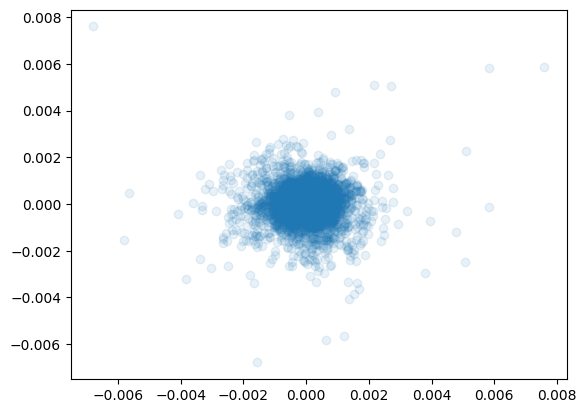

In [225]:
plt.scatter(spy_hist['logReturns'], spy_hist['logReturns'].shift(1), alpha=0.1)


In [226]:
spy_hist['logOpen']

0       5.980808
1       5.977873
2       5.978329
3       5.975462
4       5.979190
          ...   
5950    6.030480
5951    6.030012
5952    6.029820
5953    6.029940
5954    6.029892
Name: logOpen, Length: 5955, dtype: float64

In [230]:
partials = {}
cints = {}

full_autos = {}

for (datetime_obj, df) in spy_hist_date:
    if len(df)>52:
        partials[datetime_obj], cints[datetime_obj] = pacf(df['logReturns'], alpha=0.05, nlags=52)
        full_autos[datetime_obj] = acf(df['logReturns'], nlags=96)
        
        
        
partial_autocorrelations = np.zeros(
    (
        len(partials.keys()),
        len(partials[list(partials.keys())[0]])
    )
)
cints_together = np.zeros(
    (
        len(partials.keys()),
        len(partials[list(partials.keys())[0]]),
        2
    )
)

autos = np.zeros(
    (
        len(full_autos.keys()),
        len(full_autos[list(full_autos.keys())[0]])
    )
)
        

for index, key in enumerate(partials.keys()):
    if len(partials[key]) == len(partial_autocorrelations[0,:]):
        partial_autocorrelations[index,:] = partials[key]
        cints_together[index,:,:] = cints[key]
        autos[index,:] = full_autos[key]
    else:
        partial_autocorrelations[index,:] = np.asarray([np.nan] * len(partial_autocorrelations[0,:]))
        autos[index,:] = np.asarray([np.nan] * len(autos[0,:]))
        cints_together[index, :, 0] = np.asarray([np.nan] * len(partial_autocorrelations[0,:]))
        cints_together[index, :, 1] = np.asarray([np.nan] * len(partial_autocorrelations[0,:]))

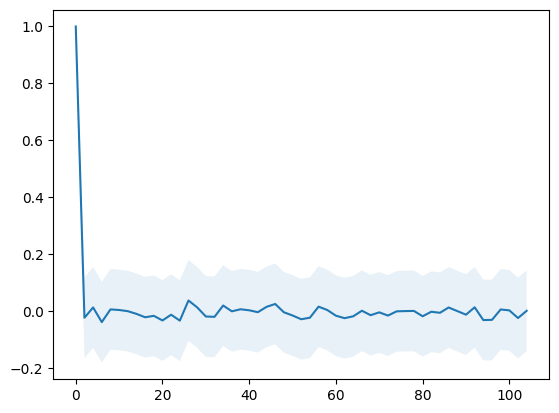

In [231]:
plt.plot(2*np.arange(len(partial_autocorrelations[0,:])), np.nanmean(partial_autocorrelations, axis=0))
plt.fill_between(
    2*np.arange(len(partial_autocorrelations[0,:])), 
    np.nanmean(cints_together[:,:,0], axis=0),
    np.nanmean(cints_together[:,:,1], axis=0),
    alpha=0.1
)

In [42]:
spy_hist['logReturns']

0      -0.000167
1      -0.000084
2       0.000848
3      -0.000115
4      -0.000377
          ...   
6252    0.000406
6253    0.000109
6254    0.000020
6255   -0.000002
6256    0.000179
Name: logReturns, Length: 6257, dtype: float64

In [43]:
log_returns

Date            
2024-01-11  0      -0.000167
            1      -0.000084
            2       0.000848
            3      -0.000115
            4      -0.000377
                      ...   
2024-02-28  6252    0.000406
            6253    0.000109
            6254    0.000020
            6255   -0.000002
            6256    0.000179
Length: 6257, dtype: float64

In [45]:
partials = {}
cints = {}

full_autos = {}

for (datetime_obj, df) in spy_hist_date:
    if len(df)>97:
        partials[datetime_obj], cints[datetime_obj] = pacf(df['Close'], alpha=0.05, nlags=96)
        full_autos[datetime_obj] = acf(df['Close'], nlags=96)

In [46]:
partial_autocorrelations = np.zeros(
    (
        len(partials.keys()),
        len(partials[list(partials.keys())[0]])
    )
)
cints_together = np.zeros(
    (
        len(partials.keys()),
        len(partials[list(partials.keys())[0]]),
        2
    )
)

autos = np.zeros(
    (
        len(full_autos.keys()),
        len(full_autos[list(full_autos.keys())[0]])
    )
)

full_autos[datetime_obj] = acf(df['Close'])

for index, key in enumerate(partials.keys()):
    if len(partials[key]) == len(partial_autocorrelations[0,:]):
        partial_autocorrelations[index,:] = partials[key]
        cints_together[index,:,:] = cints[key]
        autos[index,:] = full_autos[key]
    else:
        partial_autocorrelations[index,:] = np.asarray([np.nan] * len(partial_autocorrelations[0,:]))
        autos[index,:] = np.asarray([np.nan] * len(autos[0,:]))
        cints_together[index, :, 0] = np.asarray([np.nan] * len(partial_autocorrelations[0,:]))
        cints_together[index, :, 1] = np.asarray([np.nan] * len(partial_autocorrelations[0,:]))

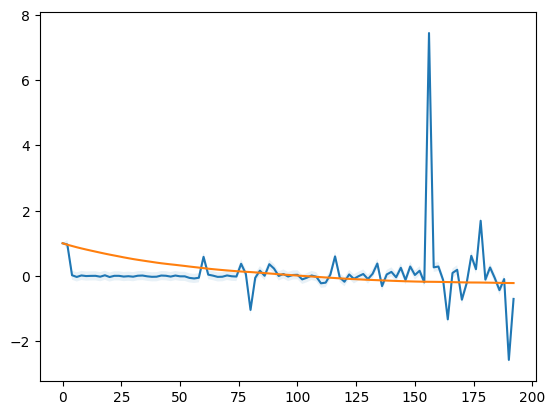

In [47]:
plt.plot(2*np.arange(len(partial_autocorrelations[0,:])), np.nanmean(partial_autocorrelations, axis=0))
plt.fill_between(
    2*np.arange(len(partial_autocorrelations[0,:])), 
    np.nanmean(cints_together[:,:,0], axis=0),
    np.nanmean(cints_together[:,:,1], axis=0),
    alpha=0.1
)
plt.plot(2*np.arange(len(autos[0,:])), np.nanmean(autos, axis=0))


(-1.0, 1.0)

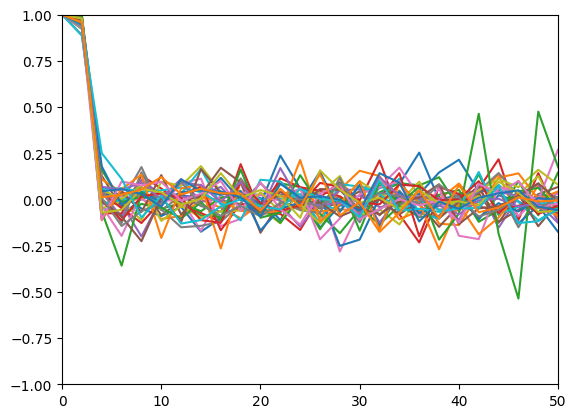

In [48]:
plt.plot(2*np.arange(len(autos[0,:])), np.transpose(partial_autocorrelations))
plt.xlim((0,50))
plt.ylim(-1,1)

(-1.0, 1.0)

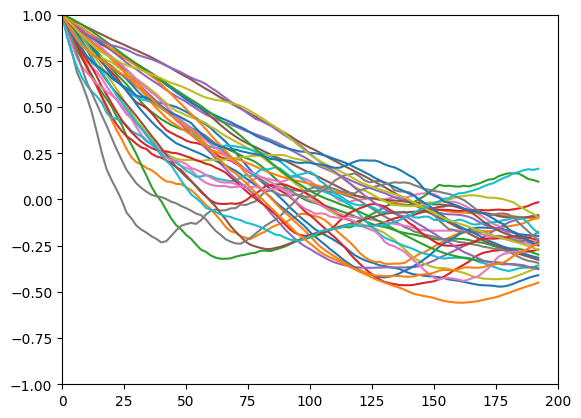

In [49]:
plt.plot(2*np.arange(len(autos[0,:])), np.transpose(autos))
plt.xlim((0,200))
plt.ylim(-1,1)

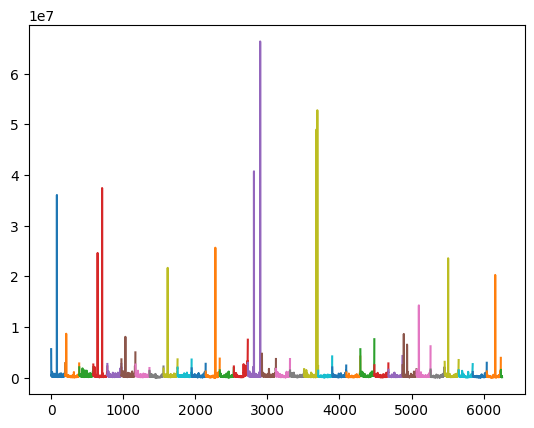

In [52]:
spy_hist.groupby('Date')['Volume'].plot()
plt.show()

In [70]:
df_mean = spy_hist.groupby('Time')['Volume'].mean()
df_std = spy_hist.groupby('Time')['Volume'].std()

(0.0, 3000000.0)

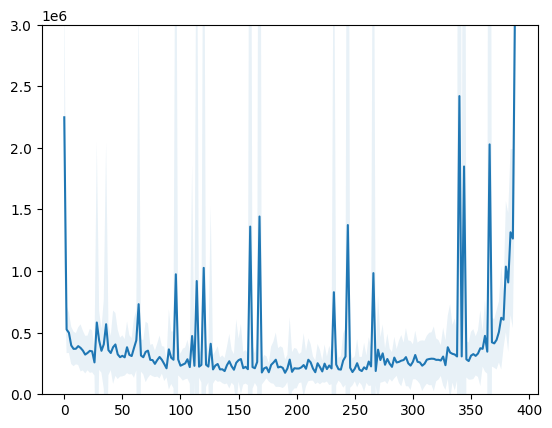

In [72]:
plt.plot(np.arange(0, 390,2),np.asarray(df_mean))
plt.fill_between(np.arange(0, 390,2), np.asarray(df_mean) - df_std, np.asarray(df_mean) + df_std, alpha=0.1)
plt.ylim(0,3*10**6)

In [73]:
df_mean = spy_hist.groupby('Time')['logReturns'].mean()
df_std = spy_hist.groupby('Time')['logReturns'].std()

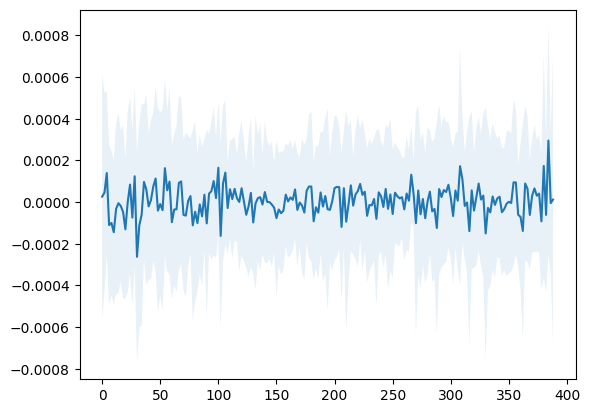

In [75]:
plt.plot(np.arange(0, 390,2),np.asarray(df_mean))
plt.fill_between(np.arange(0, 390,2), np.asarray(df_mean) - df_std, np.asarray(df_mean) + df_std, alpha=0.1)
#plt.ylim(0,3*10**6)

In [77]:
from sklearn.gaussian_process import GaussianProcessRegressor

In [151]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from sklearn.gaussian_process.kernels import ConstantKernel


X_train = np.arange(0,30,2)
y_train = spy_hist['logReturns'].iloc[1:16]


kernel = ConstantKernel(constant_value=1, constant_value_bounds=(1e-8, 1e10)) * RBF(length_scale=2, length_scale_bounds=(1e-5, 1e10))
gaussian_process = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=20)
gaussian_process.fit(X_train.reshape(-1,1), y_train)
gaussian_process.kernel_

/Users/hiroku007/miniforge3/envs/reinforcement/lib/python3.11/site-packages/sklearn/gaussian_process/_gpr.py:663: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


0.000548**2 * RBF(length_scale=0.806)

In [152]:
mean_prediction, std_prediction = gaussian_process.predict(np.arange(0,32,2).reshape(-1,1), return_std=True)

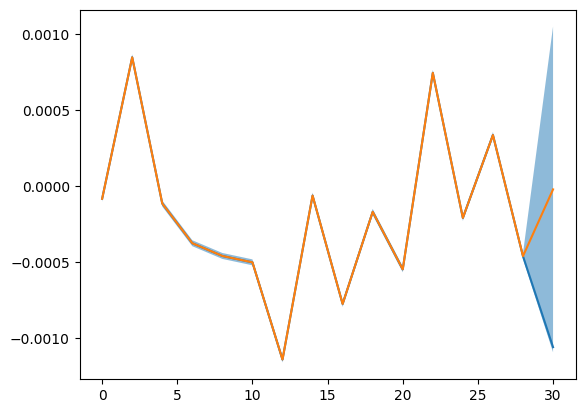

In [153]:
plt.plot(np.arange(0,32,2), spy_hist['logReturns'].iloc[1:17])
plt.plot(np.arange(0,32,2), mean_prediction)

plt.fill_between(
    np.arange(0,32,2),
    mean_prediction - 1.96 * std_prediction,
    mean_prediction + 1.96 * std_prediction,
    alpha=0.5,
    label=r"95% confidence interval",
)
#plt.ylim(np.min(spy_hist['logReturns'].iloc[:16]), np.max(spy_hist['logReturns'].iloc[:16])+10)